In [1]:
from figures import *
from subsectors import *

In [2]:
# load in data
root = "/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/"

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]

light_curves = []
periodograms = []

for sector in planet_sectors:
    light_curves.append(np.load(root + f"light_curves/{sector}_lcs.npz"))
    periodograms.append(np.load(root + f"periodograms/{sector}_periodogram.npz"))

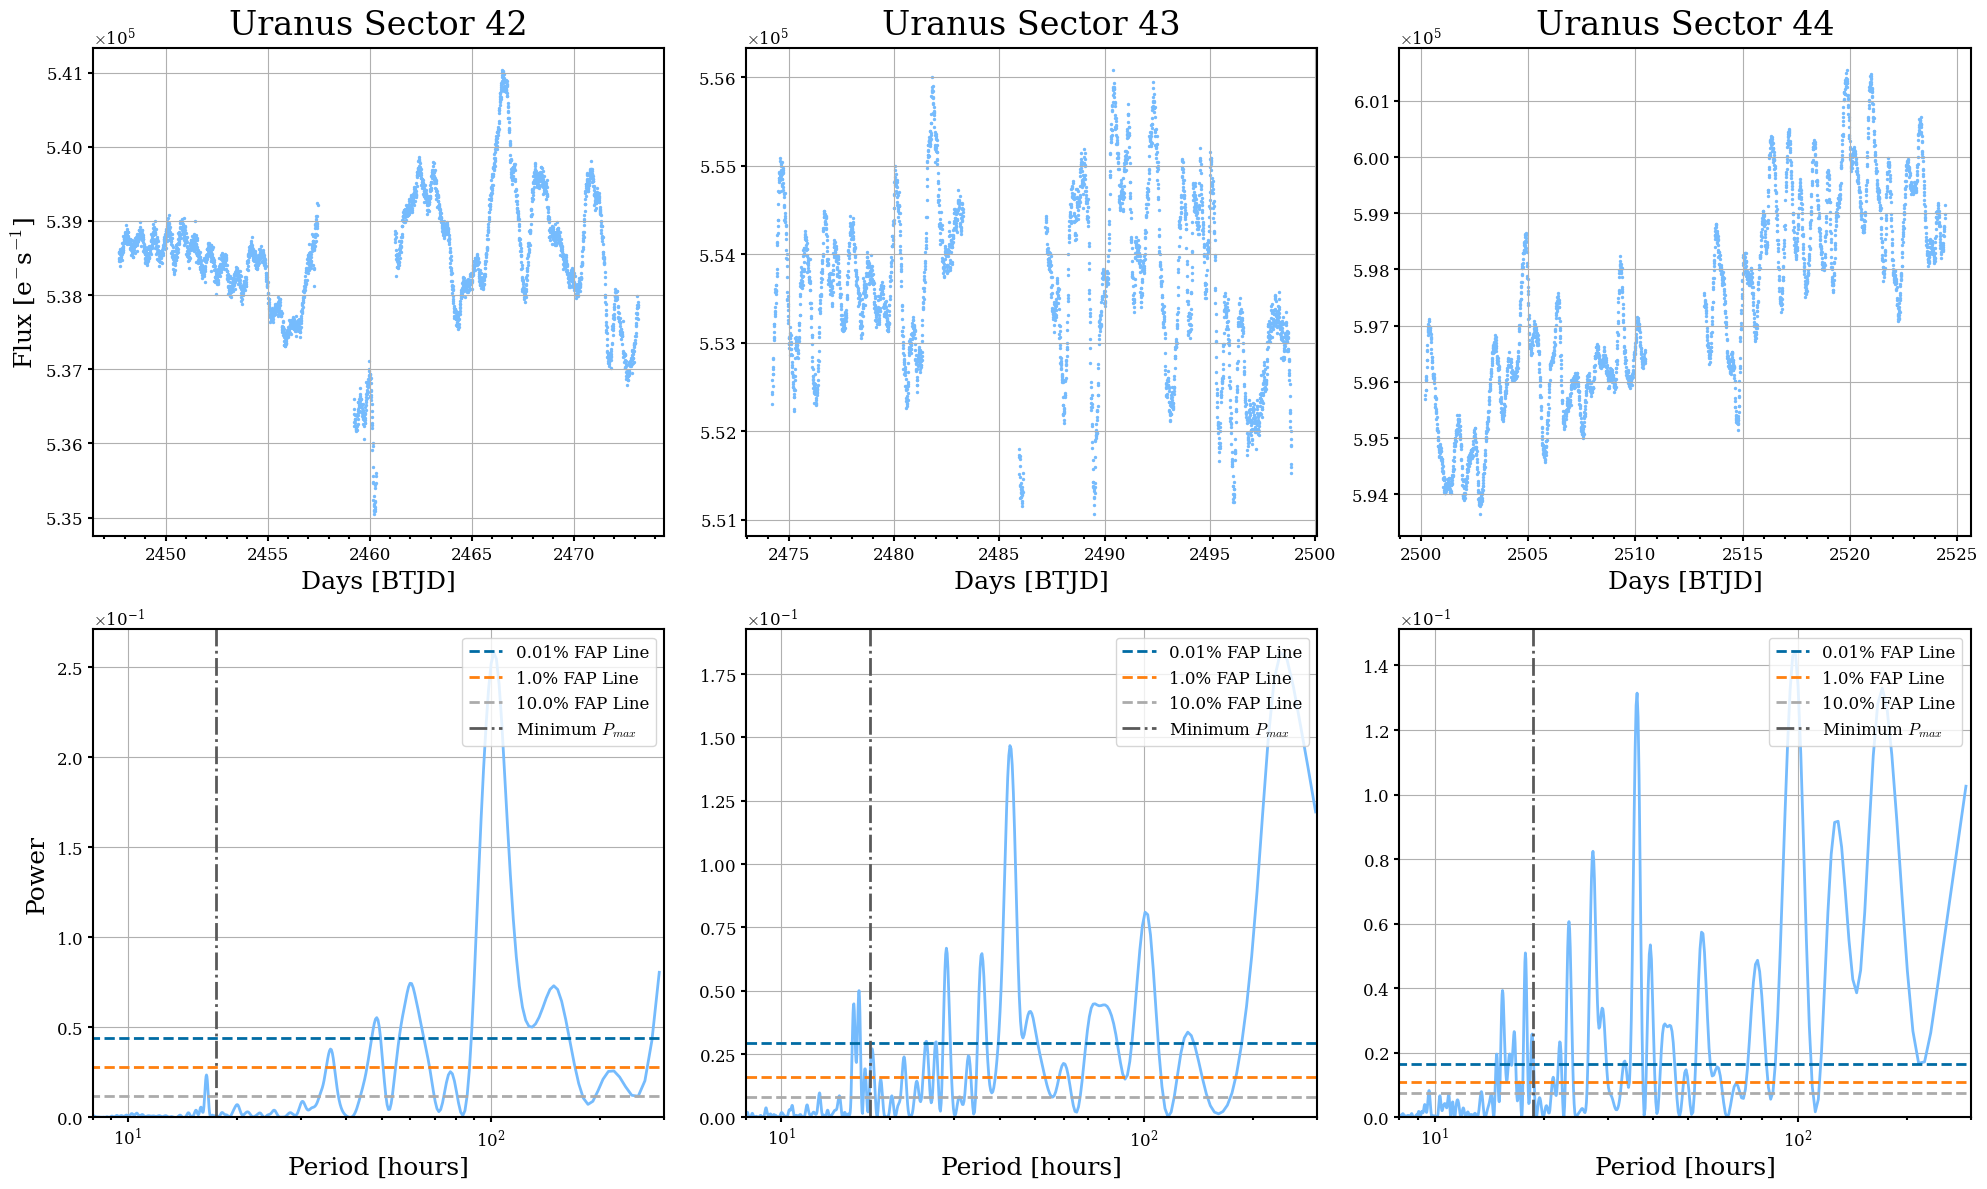

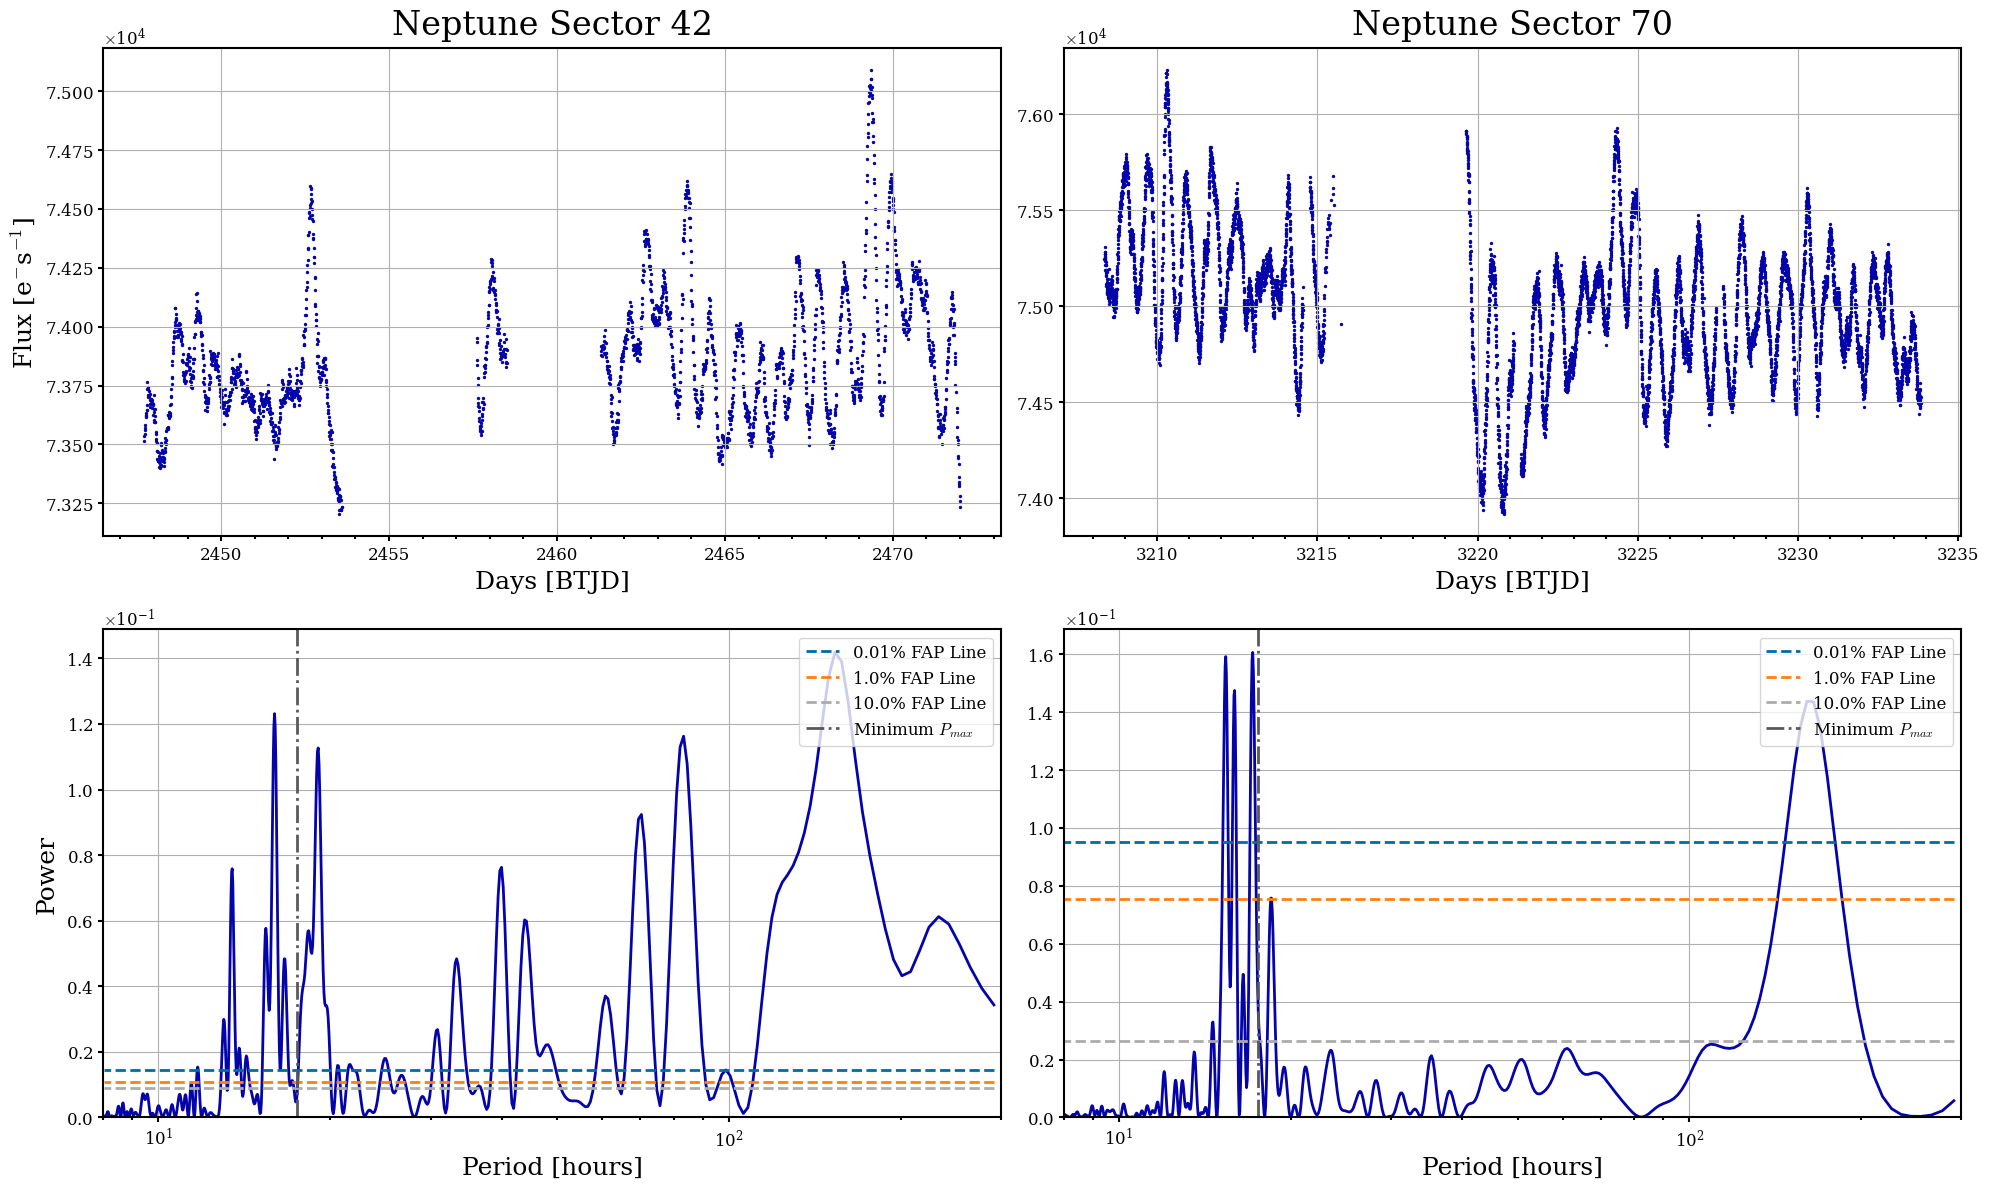

In [3]:
from figures import plot_lightcurve_and_periodogram

plot_lightcurve_and_periodogram("Uranus", 
                                light_curves[0:3], 
                                periodograms[0:3], 
                                sector_list=[42, 43, 44],
                                flux_string="orbit_corrected", xlim=[8,300])
plot_lightcurve_and_periodogram("Neptune", 
                                light_curves[3:5], 
                                periodograms[3:5], 
                                sector_list=[42, 70],
                                flux_string="orbit_corrected", xlim=[8,300])

skewness:  -0.3927276113011131
skewness:  0.8412883977430441
skewness:  -3.9135248367335222


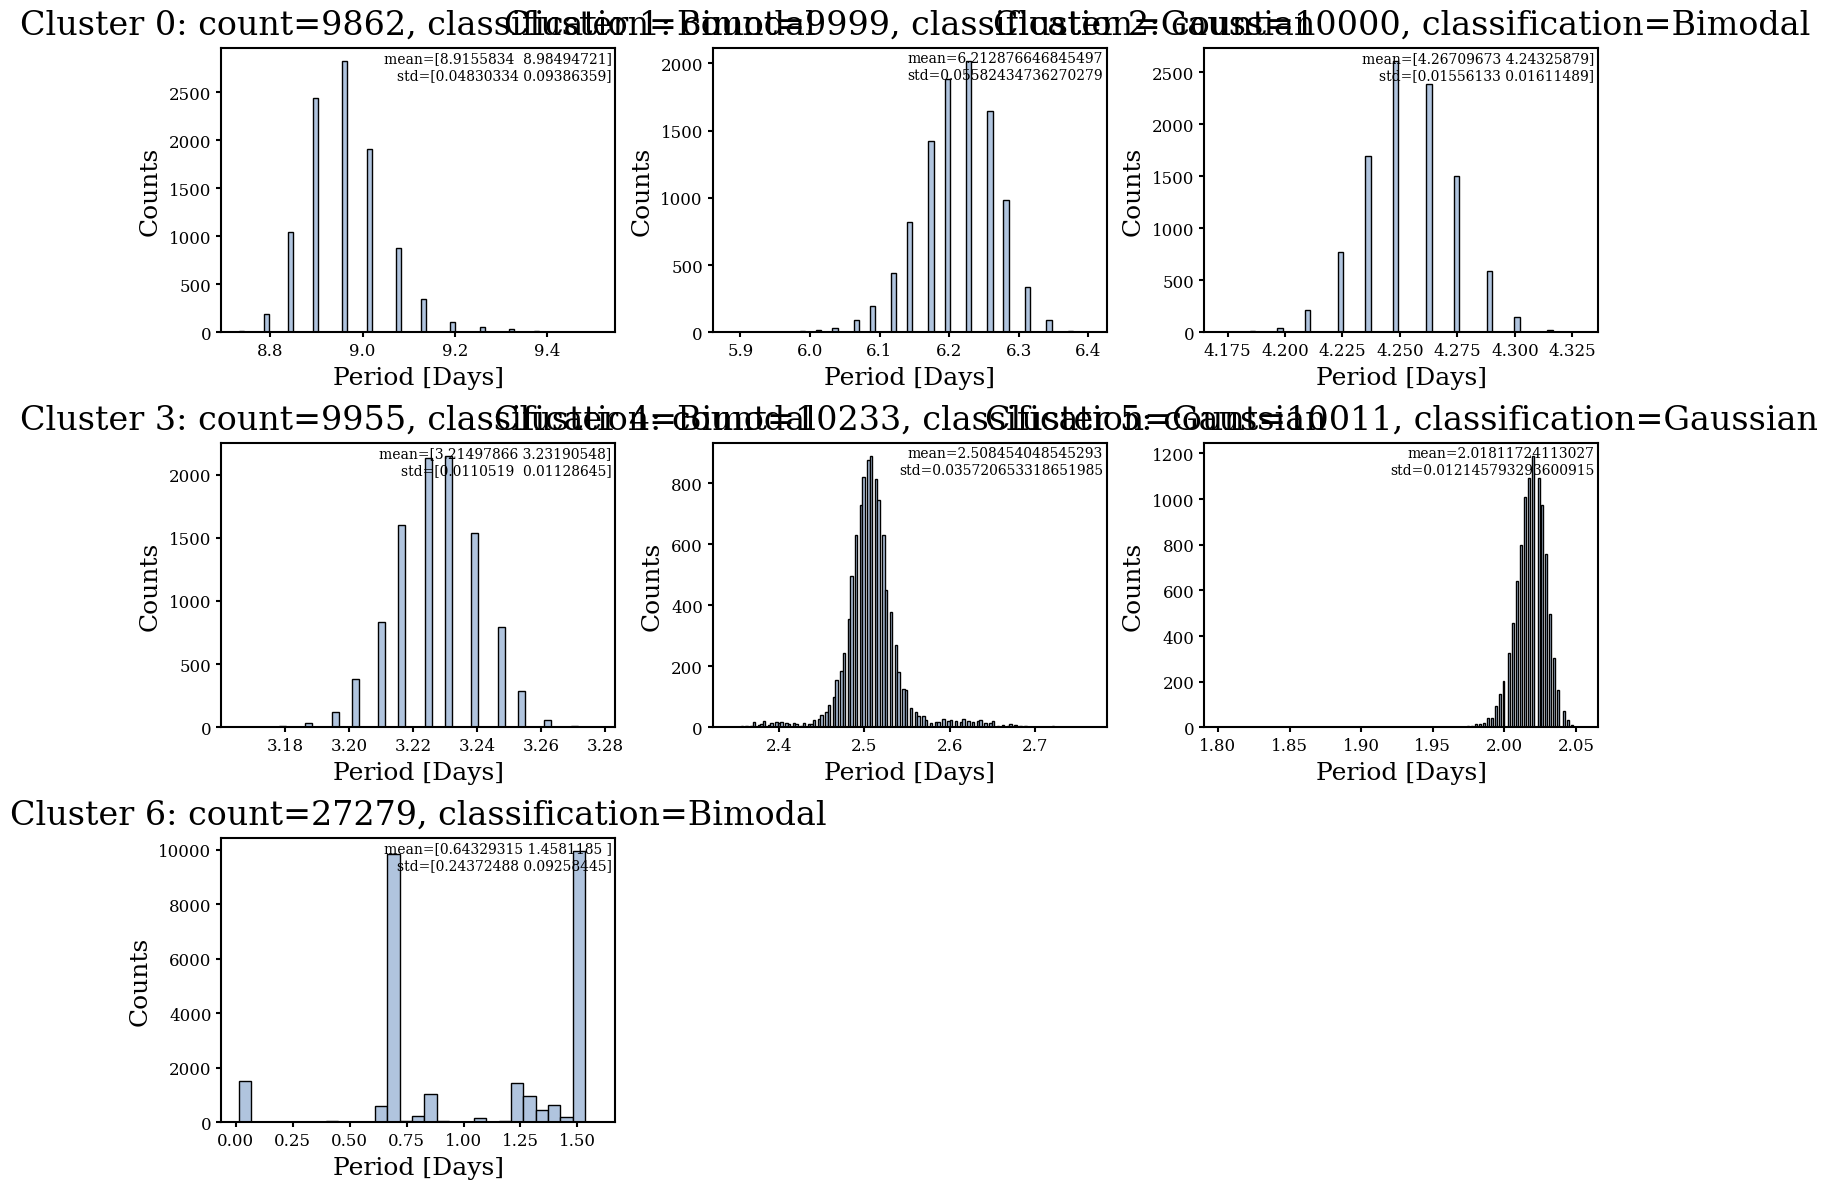

Sector: u42
4 out of 5 All means: [6.212876646845497, 2.508454048545293, 2.01811724113027, 0.6432931460943799, 1.458118501902781]
5 Peak periods from periodogram: [6.20988283 4.24341994 2.49612937 2.02067616 1.50653962]
matched means: [6.21287665 2.50845405 2.01811724 1.4581185 ]
matched stds: [0.05582435 0.03572065 0.01214579 0.09258445]

skewness:  0.1863656279341432
skewness:  0.2679939132725515
skewness:  -0.2591737452536494
skewness:  -0.20474075789078003


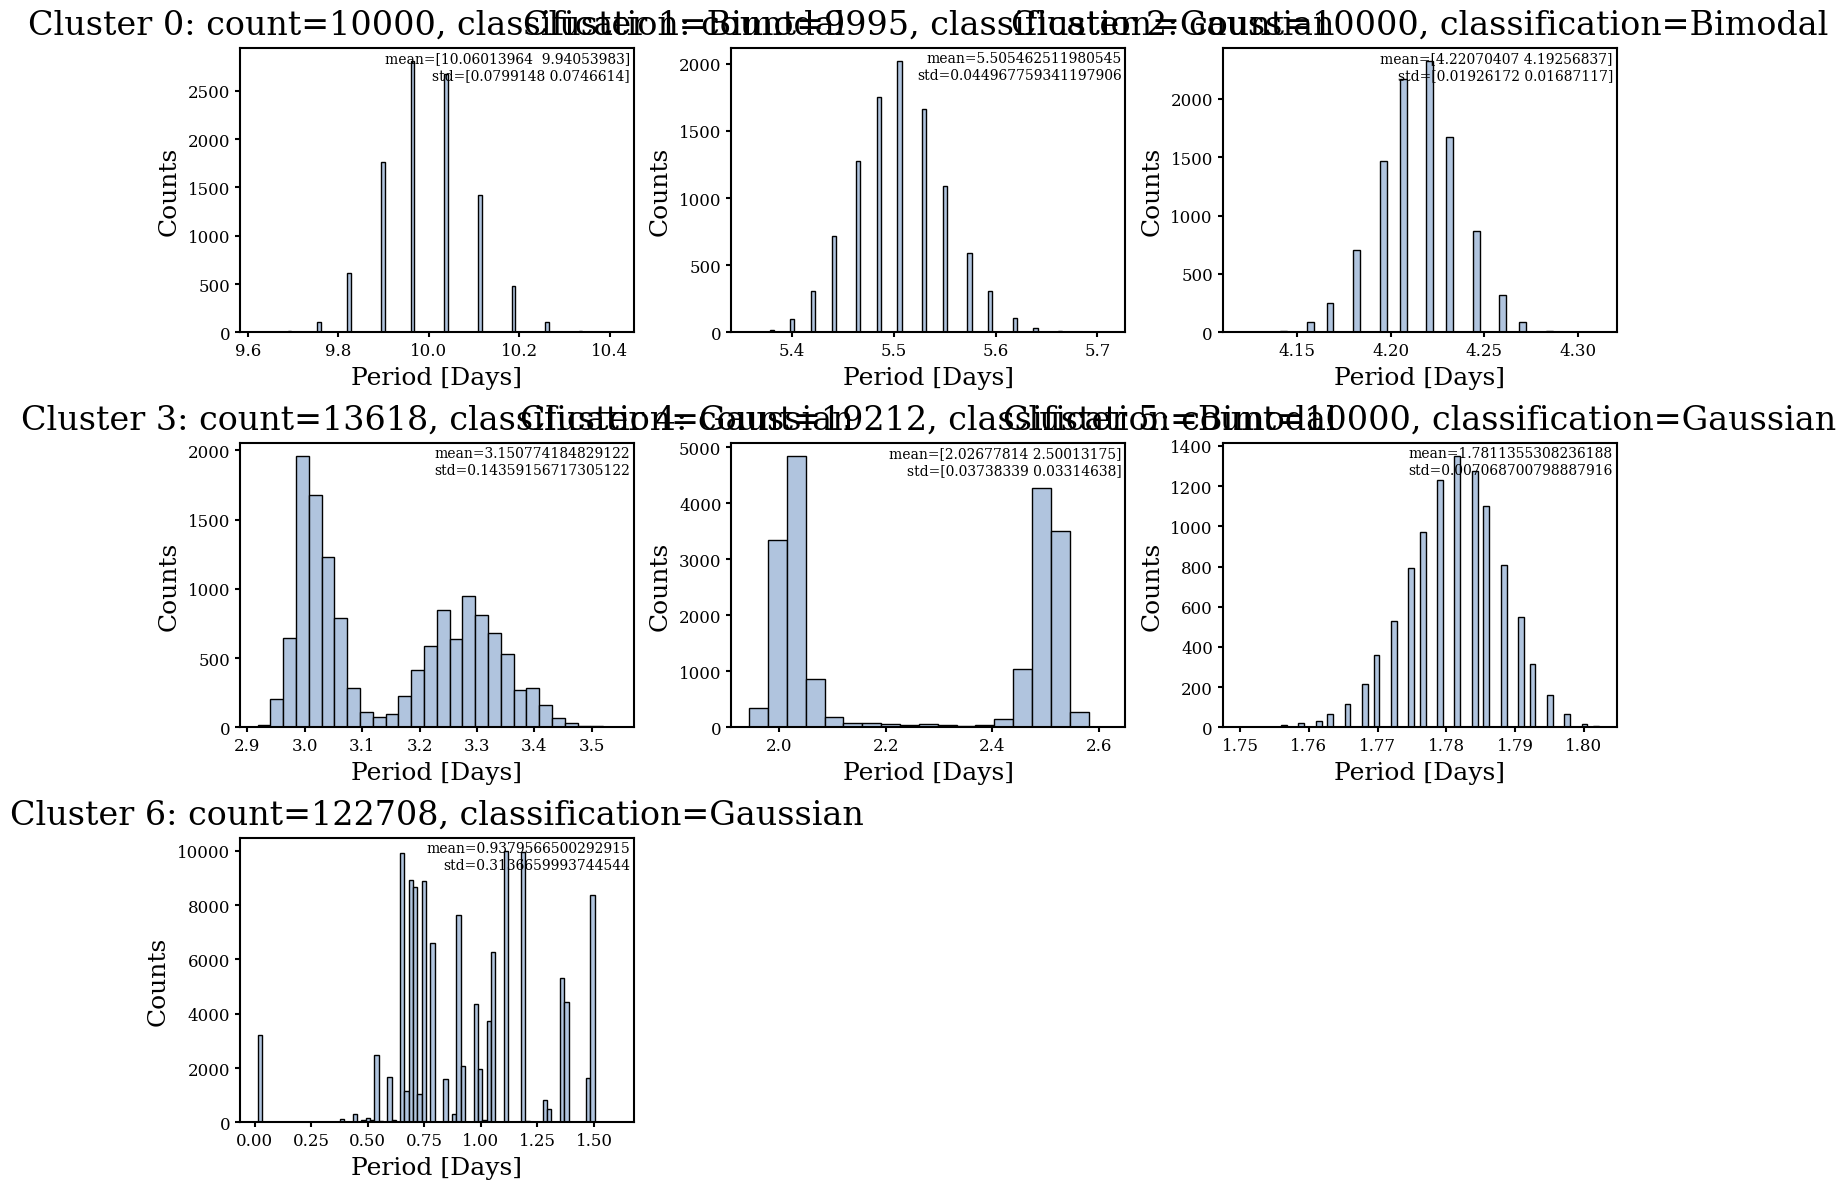

Sector: u43
6 out of 6 All means: [5.505462511980545, 3.150774184829122, 2.0267781362765906, 2.500131753707028, 1.7811355308236188, 0.9379566500292915]
18 Peak periods from periodogram: [9.88672211 5.49262339 4.18928903 3.25221122 3.05145744 2.496647
 2.02596765 1.77818743 1.48896417 1.36556935 1.18830795 1.11336961
 1.04732226 0.90870608 0.7422464  0.71025303 0.68278468 0.66087715]
matched means: [5.50546251 3.15077418 2.02677814 2.50013175 1.78113553 0.93795665]
matched stds: [0.04496776 0.14359157 0.03738339 0.03314638 0.0070687  0.313666  ]

skewness:  0.3273364978843227
skewness:  -0.1386302170694321
skewness:  0.04854598681876904
skewness:  0.6562288559337117


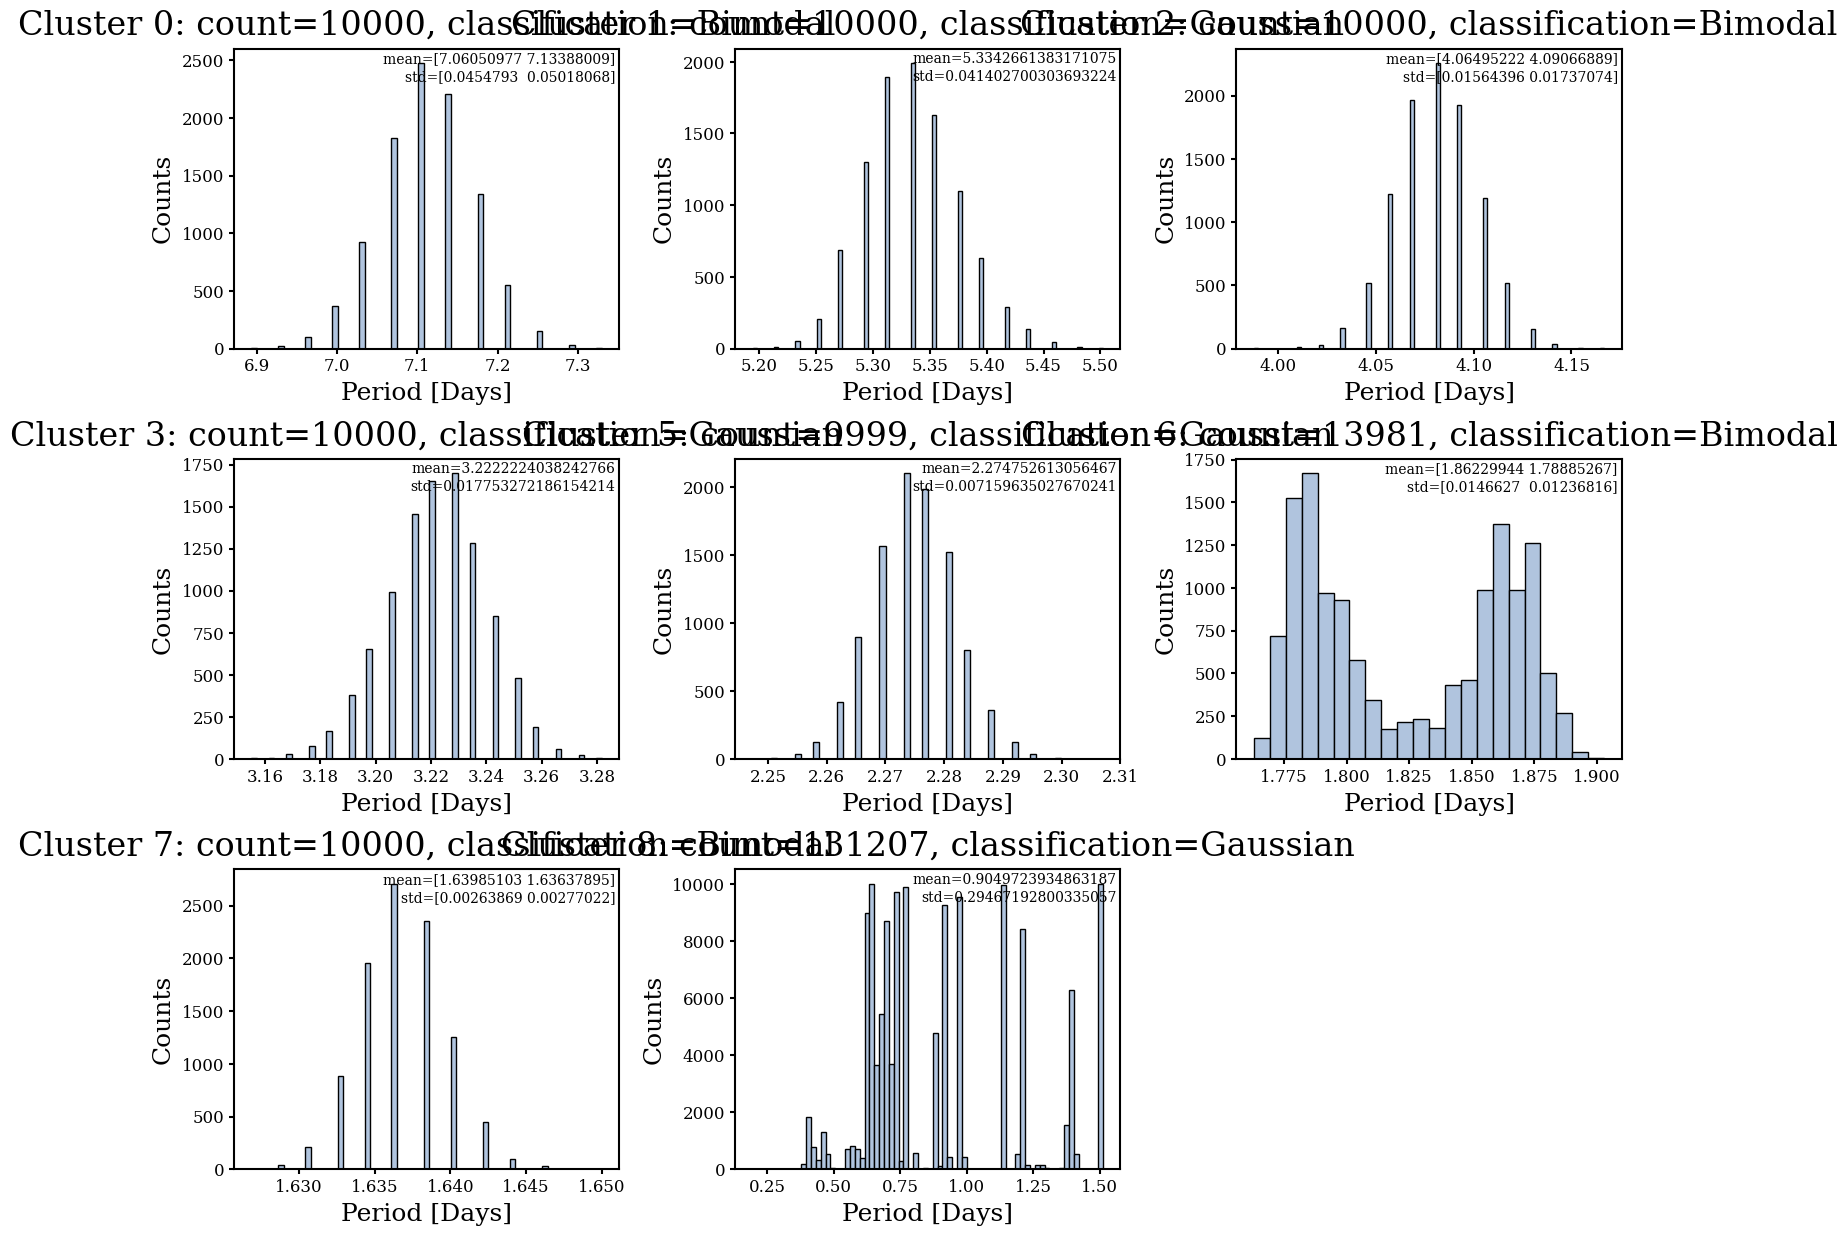

Sector: u44
5 out of 5 All means: [5.3342661383171075, 3.2222224038242766, 2.274752613056467, 1.6363789470395336, 0.9049723934863187]
24 Peak periods from periodogram: [7.13049005 5.38748137 4.10909596 3.23248882 2.49934703 2.26576319
 2.05454798 1.85066154 1.79582712 1.63808555 1.50581777 1.39331415
 1.20615255 1.13820029 0.97756718 0.9218124  0.88480533 0.77455802
 0.74139652 0.713049   0.69070274 0.6715697  0.64136683 0.61846087]
matched means: [5.33426614 3.2222224  2.27475261 1.63637895 0.90497239]
matched stds: [0.0414027  0.01775327 0.00715964 0.00277022 0.29467193]



In [ ]:
from bootstrap import save_cluster

periodogram_list = []
bootstrap_list = []
for sector in planet_sectors:
    periodogram_list.append(np.load(root + "periodograms/" + f"{sector}_periodogram.npz"))
    bootstrap_list.append(np.load(root + "bootstrap/" + f"{sector}_bootstrap.npz")["peak_periods"])

save_cluster(periodogram_list, 
             bootstrap_list, 
             [f"{sector}" for sector in planet_sectors], 
             root + "long_term_clusters/",
             eps_arr=[0.1, 0.1, 0.1, 0.1, 0.1], tolerance= 0.5,
             n_cols=3, min_prominence_arr=[0.5, 0.5, 0.5, 0.4, 5],
             plot=True)

cluster_list = []
for sector in planet_sectors:
    cluster_list.append(np.load(root + "long_term_clusters/" + f"{sector}_clustered_peaks.npz", allow_pickle=True))
for i, cluster in enumerate(cluster_list):
    print(f"Sector {planet_sectors[i]}: {len(cluster['matched_means'])} clusters found.")

In [3]:
# subsector latitude solutions

import glob 
from tqdm import tqdm

subroot = root + "subsectors"

latitudes = np.empty((len(planet_sectors), 10), dtype=object)
standard_deviations = np.empty((len(planet_sectors), 10), dtype=object)

for j, sector in enumerate(planet_sectors):
    secsubroot = subroot + "/" + sector
    mcmc_list = glob.glob(secsubroot + "/mcmc/*")

    for i, phi_file in tqdm(enumerate(mcmc_list)):
        phi_dist = np.load(phi_file, allow_pickle=True)

        if os.path.exists(secsubroot + "/latitudes/") == False:
            os.makedirs(secsubroot + "/latitudes/")

        lat_arr = np.load(secsubroot + "/latitudes/" + f"{sector}_sub{i}_latitude_solutions.npz", 
                    allow_pickle=True) 
        # print(lat_arr["lat"], lat_arr["std"])
        lat, std = take_latsol_with_largest_std(lat_arr["lat"], lat_arr["std"])

        latitudes[j, i] = lat
        standard_deviations[j, i] = std

        # print(lats.shape)



10it [00:00, 803.23it/s]
10it [00:00, 881.93it/s]
10it [00:00, 864.79it/s]
10it [00:00, 842.70it/s]
10it [00:00, 1022.48it/s]


In [4]:
sorted_latitudes, sorted_standard_deviations = sort_lat_std(latitudes, standard_deviations)

u42latsecN, u42stdsecN = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=0, secidx=0)
u43latsecN, u43stdsecN = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=0, secidx=1)
u44latsecN, u44stdsecN = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=0, secidx=2)

u42latsecS, u42stdsecS = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=1, secidx=0)
u43latsecS, u43stdsecS = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=1, secidx=1)
u44latsecS, u44stdsecS = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=1, secidx=2)

n42latsec, n42stdsec = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=0, secidx=3)
n70latsec, n70stdsec = lat_std_per_eqn(sorted_latitudes, sorted_standard_deviations, eqnidx=0, secidx=4)

TypeError: plot_subsec_latsols() missing 1 required positional argument: 'eqn'

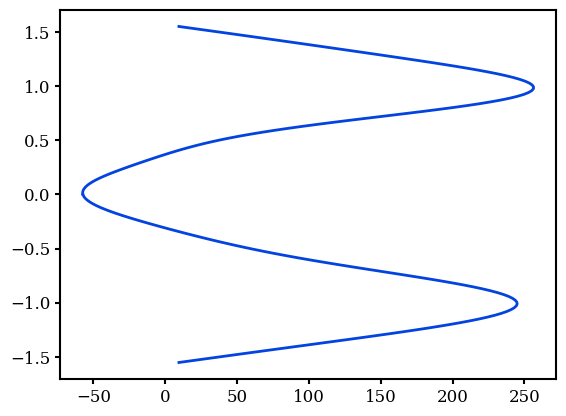

In [ ]:
uranus_eqn_N = sromovsky2012_odd_N
uranus_eqn_S = sromovsky2012_odd_S
neptune_eqn = sromovsky1993_four

phi=np.radians(np.arange(-90, 90, 1))
phin=np.radians(np.arange(0, 90, 1))
phis=np.radians(np.arange(0, 90, 1))
thislat, thisstd = u43latsecN, u43stdsecN
eqn = uranus_eqn_N

uranus_markers = ['o', '^', 's']

plt.plot(uranus_eqn_N(phin), phin, color='xkcd:blue', label='Sromovsky 2012 (N)', linewidth=2)
plt.plot(uranus_eqn_S(phis), -phis, color='xkcd:blue', label='Sromovsky 2012 (S)', linewidth=2)
color='xkcd:light blue'

for i, (latsec, stdsec) in enumerate(zip(uranus_ss_lats, uranus_ss_stds)):
    plot_subsec_latsols(latsec[0], stdsec[0], uranus_eqn_N, fmt=uranus_markers[i], color=color)
    plot_subsec_latsols(latsec[1], stdsec[1], uranus_eqn_S, flip=True, fmt=uranus_markers[i], color=color)
plt.show()


plt.plot(neptune_eqn(phi), phi, color='xkcd:green', label='Sromovsky 1993 (N)', linewidth=2)
plot_subsec_latsols(n42latsec, n42stdsec, neptune_eqn, fmt='o', color='xkcd:light green')
plot_subsec_latsols(n42latsec, n42stdsec, neptune_eqn, flip=True, fmt='o', color='xkcd:light green')

plt.show()

plt.plot(neptune_eqn(phi), phi, color='xkcd:green', label='Sromovsky 1993 (N)', linewidth=2)
plot_subsec_latsols(n70latsec, n70stdsec, neptune_eqn, fmt='o', color='xkcd:light green')
plot_subsec_latsols(n70latsec, n70stdsec, neptune_eqn, flip=True, fmt='o', color='xkcd:light green')
plt.show()

In [5]:
def plot_mosaic_latitudes(mosaic_data, eqns, lats, stds, plot_colors, 
                          title, planet, ss_lats, ss_stds, sector=None, 
                          vmin_percentile=None, vmax_percentile=None):
    binary = sns.color_palette("viridis", as_cmap=True)
    #plt.style.use('viridis')

    phi = np.linspace(-np.pi/2, np.pi/2, 361)

    fig = plt.figure(figsize=(10, 6))
    if sector is not None:
        fig.suptitle(f"Sector {sector}, {title}", fontsize=16, x=0.05, horizontalalignment='left')

    gs = gridspec.GridSpec(2, 6, height_ratios=[1, 1])

    ax = fig.add_subplot(gs[0:2, 0:6])
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    if planet == "Neptune":
        # phi = np.linspace(-np.pi/2, 0, 181)
        lat, stds = np.array(lats), np.array(stds)
        plot_neptune_equations(ax, phi, plot_colors, h_band=False)
        for i, equation in enumerate(eqns):
            plot_lat_solutions(ax, lat[i], stds[i], equation, 42, plot_colors[i])
        plot_subsec_latsols(ax, ss_lats, ss_stds, eqns[0], fmt='o', color=plot_colors[0])
        plot_subsec_latsols(ax, ss_lats, ss_stds, eqns[0], flip=True, fmt='o', color=plot_colors[0])

        ax.set_ylim(-90, 90)
        ax.set_xlim(-500, 400)

    elif planet == "Uranus":
        plot_uranus_equations(ax, phi, plot_colors)
        markers = ["o", "^", "s"]
        for j, lat in enumerate(lats):
            for i, equation in enumerate(eqns):
                plot_lat_solutions(ax, lat[i], stds[j][i], equation, 42, plot_colors[i], even=False, marker=markers[j])
        for i, (latsec, stdsec) in enumerate(zip(ss_lats, ss_stds)):
            plot_subsec_latsols(ax, latsec[0], stdsec[0], eqns[0], fmt=markers[i], color=plot_colors[0])
            plot_subsec_latsols(ax, latsec[1], stdsec[1], eqns[1], flip=True, fmt=markers[i], color=plot_colors[0])
        ax.set_ylim(-90,90)
        ax.set_xlim(-100, 300)

    ax.set_xlabel(r"Wind Speed $[ms^{-1}]$")
    ax.xaxis.set_label_position('top') 

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    x1n = np.linspace(-180, 181, 30)

    def forward(x):
        return np.interp(x, x1n, np.linspace(xlim[0], xlim[1], 30))

    def inverse(x):
        return np.interp(x, np.linspace(xlim[0], xlim[1], 30), x1n)

    if planet == "Neptune":
        # mosaic_data = mosaic_data[180:360, :]
        mosaic_data = mosaic_data/np.nanmean(mosaic_data)
        im = ax.imshow(mosaic_data, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], aspect='auto', cmap=binary, 
                       vmin=np.percentile(mosaic_data, vmin_percentile), vmax=np.percentile(mosaic_data, vmax_percentile))
        
        ax.legend(loc='center right')
    elif planet == "Uranus":
        # mosaic_data = mosaic_data[0:180, :]
        mosaic_data = mosaic_data/np.nanmean(mosaic_data)
        im = ax.imshow(mosaic_data, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], aspect='auto', cmap=binary, 
                       vmin=np.percentile(mosaic_data, vmin_percentile), vmax=np.percentile(mosaic_data, vmax_percentile))
        ax.legend(loc='center right')

    fig.colorbar(im, cax=cax, label=r"Normalized Flux $[e^{-}s^{-1}]$")
    ax.set_ylabel(r"Latitude $[{^\circ}]$")

    secax = ax.secondary_xaxis("bottom", functions=(inverse, forward))

    secax.set_xticks(np.linspace(-180, 180, 13))  # longitude ticks
    secax.set_xticklabels([f"{val:.0f}" for val in np.linspace(-180, 180, 13)])
    secax.set_xlabel(r"Longitude $[{^\circ}]$")

    if title:
        fig.suptitle(title, fontsize=36/2)
    # return all_bright_points

def plot_summed_mosaics(summed_data, eqns, lats, stds, plot_colors, 
                        planet, ss_lats, ss_stds, sector=None, save=False, log=True, clip_percentile=97, 
                        gradient=False, vmin_percentile=None, vmax_percentile=None):
    # summed_data = None
    # for dir in directories:
    #     for file in os.listdir(dir):
    #         if file.endswith('.fits'):
    #             #print(file)
    #             hdul = fits.open(os.path.join(dir, file))
    #             data = hdul[0].data
    #             summed_data = data if summed_data is None else summed_data + data
    #             hdul.close()

    if gradient:
        lat_gradient = np.abs(np.gradient(summed_data)[1])
    else: 
        lat_gradient = summed_data
        
    #clip lat_gradient at 99th percentile for better visualization
    lat_gradient_clipped = np.clip(lat_gradient, 0, np.percentile(lat_gradient, clip_percentile))

    # set max values of lat_gradient to the mean 
    lat_gradient_clipped[lat_gradient_clipped == np.percentile(lat_gradient, clip_percentile)] = np.median(lat_gradient)

    title = None # (f"{planet} {sector}")
    plot_mosaic_latitudes(lat_gradient_clipped, eqns, lats, stds,
                          plot_colors, title, planet, ss_lats, ss_stds,
                          sector=None,vmin_percentile=vmin_percentile, vmax_percentile=vmax_percentile)
    
    plt.tight_layout()
    if save:
        plt.savefig(f"{planet}_{sector}_opal.png", transparent=True, dpi=600)
    else:
        plt.show()


KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u42_latitude_solutions.npz' with keys: lat, std)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u43_latitude_solutions.npz' with keys: lat, std)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u44_latitude_solutions.npz' with keys: lat, std)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/n42_latitude_solutions.npz' with keys: lat, std)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/n70_latitude_solutions.npz' with keys: lat, std)


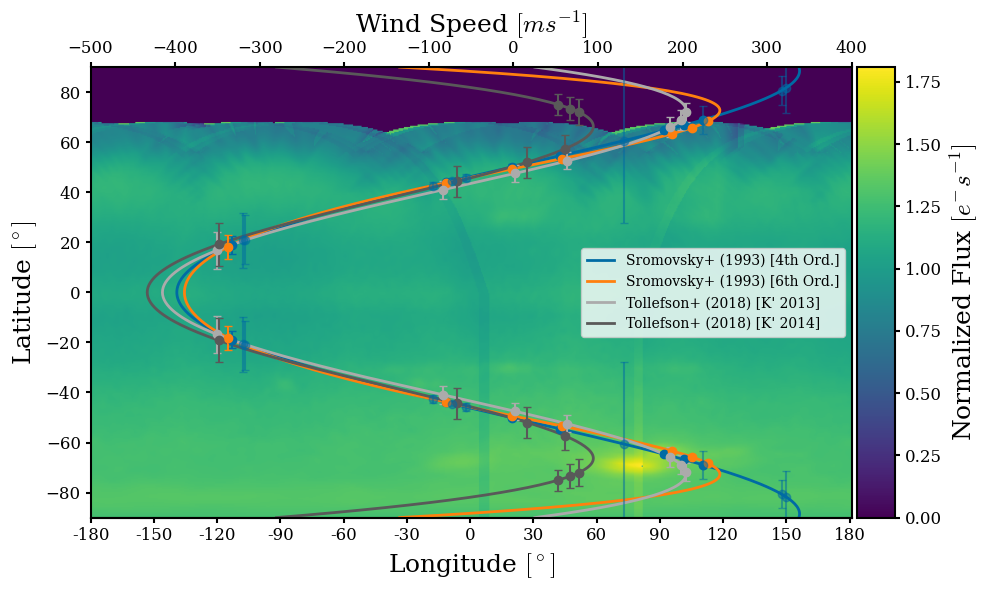

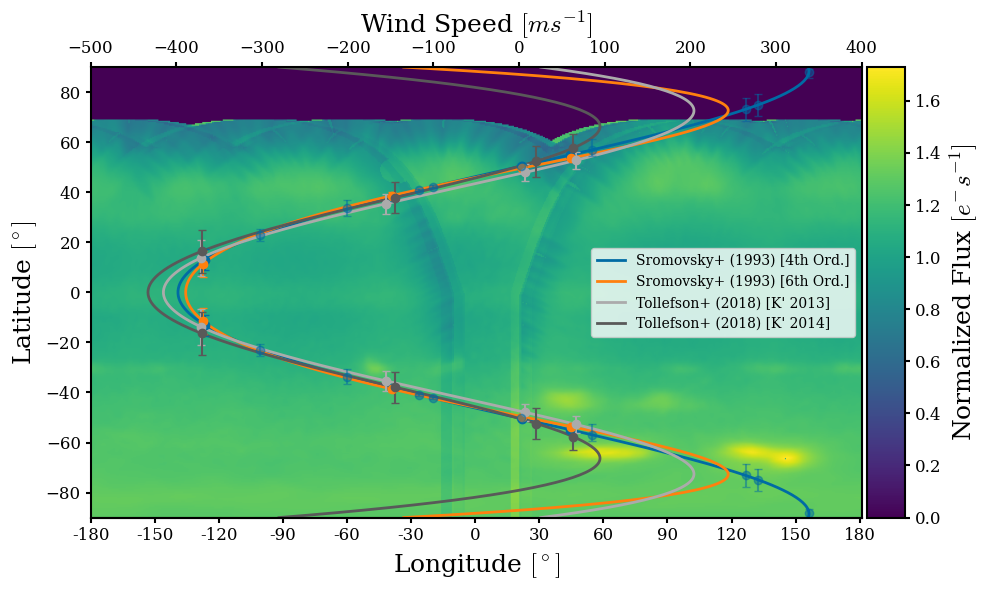

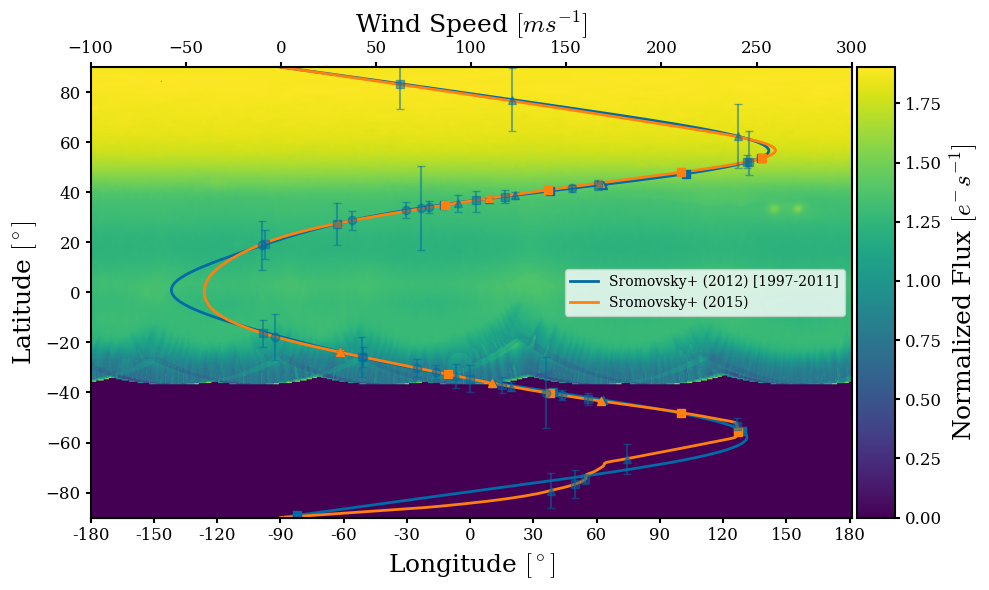

In [7]:
# lets make the opal maps 

opal_root = root + "OPAL/"
directories = [opal_root + "neptune_2021/a/", 
               opal_root + "neptune_2021/b/", 
               opal_root + "neptune_2023/a/", 
               opal_root + "neptune_2023/b/",
               opal_root + "uranus_2021/a/",
               opal_root + "uranus_2021/b/"]

root = '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/'
names = ["u42", "u43", "u44", "n42", "n70"]
new_every_lat, new_every_std = [], []
for i, latsol in enumerate(names):
    file_name = root + f"latitudes/{names[i]}_latitude_solutions.npz"
    lat = np.load(file_name, allow_pickle=True)
    print(lat.keys())
    new_every_lat.append(lat['lat'])
    new_every_std.append(lat['std'])

u42_lat, u42_std = new_every_lat[0], new_every_std[0]
u43_lat, u43_std = new_every_lat[1], new_every_std[1]
u44_lat, u44_std = new_every_lat[2], new_every_std[2]

n42_lat, n42_std = new_every_lat[3], new_every_std[3] # mask the f_0 = f solution
n70_lat, n70_std = new_every_lat[4], new_every_std[4]


n42_lat, n42_std = take_latsol_with_largest_std(n42_lat, n42_std)
n70_lat, n70_std = take_latsol_with_largest_std(n70_lat, n70_std)

u42_lat, u42_std = take_latsol_with_largest_std(u42_lat, u42_std)
u43_lat, u43_std = take_latsol_with_largest_std(u43_lat, u43_std)
u44_lat, u44_std = take_latsol_with_largest_std(u44_lat, u44_std)

#make 2nd and 4th rows of u42_lat negative

neg_u42_lat = make_rows_negative(u42_lat, [1, 3])
neg_u43_lat = make_rows_negative(u43_lat, [1, 3])
neg_u44_lat = make_rows_negative(u44_lat, [1, 3])

eqns = [sromovsky1993_four, sromovsky1993_six, tollefson2013_kp, tollefson2014_kp]

ur_eqns = [sromovsky2012_odd_N, sromovsky2015_N]

new_neg_ur_42_lat, new_u42_std = sort_ur_to_eqns(neg_u42_lat, u42_std)
new_neg_ur_43_lat, new_u43_std = sort_ur_to_eqns(neg_u43_lat, u43_std)
new_neg_ur_44_lat, new_u44_std = sort_ur_to_eqns(neg_u44_lat, u44_std)

div_stack_n21, data_stack_n21 = merge_pointings(directories[0], directories[1])
div_stack_n23, data_stack_n23 = merge_pointings(directories[2], directories[3])
div_stack_u21, data_stack_u21 = merge_pointings(directories[4], directories[5])

uranus_ss_lats = [[u42latsecN, u42latsecS], [u43latsecN, u43latsecS], [u44latsecN, u44latsecS]]
uranus_ss_stds = [[u42stdsecN, u42stdsecS], [u43stdsecN, u43stdsecS], [u44stdsecN, u44stdsecS]]

bright_points_n21 = plot_summed_mosaics(div_stack_n21, eqns, n42_lat, n42_std, plot_colors_rgb, 
                    "Neptune", n42latsec, n42stdsec, sector=2021, clip_percentile=100, save=True, vmin_percentile=0, vmax_percentile=100)
bright_points_n23 = plot_summed_mosaics(div_stack_n23, eqns, n70_lat, n70_std, plot_colors_rgb, 
                    "Neptune", n70latsec, n70stdsec, sector=2023, clip_percentile=100, save=True, vmin_percentile=0, vmax_percentile=100)
bright_points_u21 = plot_summed_mosaics(div_stack_u21, ur_eqns, [new_neg_ur_42_lat, new_neg_ur_43_lat, new_neg_ur_44_lat], 
                    [new_u42_std, new_u43_std, new_u44_std], plot_colors_rgb, 
                    "Uranus", uranus_ss_lats, uranus_ss_stds,sector=2021, clip_percentile=100, save=True, vmin_percentile=0, vmax_percentile=100)

In [ ]:
def plot_heatmap(axs, time_stack, frequency, max_frequency, power, fap_stack, min_per, max_per,
                 btjd_offset=2400, round_decimals=1,
                 gap_factor=3, vmin=0, vmax=1, output_table=False,
                 xlim=None):

    period_limit = 1/max_frequency   # in hours

    bin_starts, bin_ends = get_bin_edges(time_stack,
                                         btjd_offset=btjd_offset,
                                         round_decimals=round_decimals)
    
    # Insert a dummy bin if there's a large data gap
    bin_starts, bin_ends, gap_idx = insert_gap_bin(bin_starts, bin_ends,
                                                   gap_factor=gap_factor)
    insert_bins = np.insert(bin_starts, gap_idx, bin_ends[gap_idx - 1])
    bin_starts =  np.concatenate([insert_bins, [bin_ends[-1]]])
    new_power = []
    time_ranges = []
    tot_time = 0

    period_grid = np.linspace(min_per, max_per, 100)
    peak_freqs, periods = [], []
    for i, time in enumerate(time_stack):
        time = time - 2457000
        start_time = np.round(time[0], decimals=round_decimals + 1)
        end_time = np.round(time[-1], decimals=round_decimals + 1)
        range_time = np.round(time[-1] - time[0], decimals=round_decimals + 1)
        tot_time += range_time
        peak_frequencies, power_vals = get_peak_frequencies(frequency[i], 
                                                            power[i], 
                                                            np.full_like(frequency[i], 0))
        mask = peak_frequencies > max_frequency
        peaks_below_limit, power_below_limit = peak_frequencies[mask], power_vals[mask]

        # if len(peaks_below_limit) == 0:
        #     continue
        
        peak_freqs.append(peaks_below_limit[np.argmax(power_below_limit)])
        period = 24 / peaks_below_limit[np.argmax(power_below_limit)]
        periods.append(period)
        output_period = np.round(period, decimals=2)

        if output_table:
            if (np.max(power_below_limit) < fap_stack[i]) or (period > period_limit):
                print(f" & No Peak & {start_time} - {end_time} & {range_time} \\\\")
            else:
                print(f" & {output_period} & {start_time} - {end_time} & {range_time} \\\\")

        period_periods = np.flip(24/frequency[i])
        period_power = np.flip(np.array(power[i], dtype=float))

        # Find the valid period range in your native data
        min_period = period_periods.min()
        max_period = period_periods.max()

        # Create output array filled with NaN
        resamp_period_power = np.full_like(period_grid, np.nan, dtype=float)

        # Mask for valid period range
        valid_mask = (period_grid >= min_period) & (period_grid <= max_period)

        # Interpolate only within valid range
        resamp_period_power[valid_mask] = np.interp(period_grid[valid_mask], 
                                                    period_periods, 
                                                    period_power)
        
        new_power.append(resamp_period_power)
        time_ranges.append(range_time)

    print(f"TOTAL BIN TIME: {tot_time}")
    new_power = np.array(new_power)
    time_ranges = np.array(time_ranges)
    print(f"time ranges: {time_ranges}")

    print(time_ranges[gap_idx - 1], time_ranges[gap_idx])
    print(bin_starts[gap_idx - 1], bin_starts[gap_idx], bin_starts[gap_idx + 1])
    dummy_row = np.full_like(new_power[0], np.nan)  # NaN instead of value
    gap_power = np.insert(new_power, gap_idx, dummy_row, axis=0)

    dummy_gap = bin_starts[gap_idx] - bin_starts[gap_idx-1]
    gap_time_ranges = np.insert(time_ranges, gap_idx, dummy_gap)  # Insert a zero for the gap

    stretch_power, stretched_rows = expand_by_time_ranges(gap_power, gap_time_ranges, scale=20)
    print(gap_power.shape)
    print(stretch_power.shape)
    print(gap_time_ranges.shape)
    print(f"stretched_rows: {len(stretched_rows)}")

    # Create colormap that shows NaN as white
    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color="white")

    axs.imshow(stretch_power, interpolation='nearest', aspect='auto',
                    origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)

    period_range = np.arange(xlim[0], xlim[1] + 1, 2)
    axs.set_yticks(np.linspace(0, 99, len(period_range)), period_range, fontsize=12)
    x_ticks = np.cumsum([0] + [s.shape[0] for s in stretched_rows])
    x_labels = [f"{t:.1f}" for t in bin_starts]

    print(f"x_ticks: {x_ticks}")
    print(f"x_labels: {x_labels}")

    axs.set_xlabel(f"Days [BTJD - {btjd_offset}]")
    # axs.set_title(title)
    axs.set_xticks(x_ticks)
    axs.set_xticklabels(x_labels, rotation=45, ha='right')

    # Add "Data gap" label
    if gap_idx is not None:
        axs.text(x_ticks[gap_idx] + 10, 50, "data gap", ha="center", va="center",
                 rotation=90, fontsize=18, color="black",
                 bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

    return np.array(peak_freqs), np.array(periods), np.array(stretch_power), np.array(gap_time_ranges), stretched_rows


In [57]:

def plot_subsector_heatmap(planet, 
                           subtimes, subfluxes, 
                           subfreqs, subpower, subfap, 
                           labels, max_freq, offset, 
                           min_per, max_per, xlim=None):

    if xlim is None:
        xlim = [min_per, max_per]

    fig = plt.figure(figsize=(20, 18))
    gs = fig.add_gridspec(nrows=3, ncols=7, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1, 1, 1, 1, 0.1], wspace=0.3)

    if planet == "Neptune":

        # light curves
        ax1 = fig.add_subplot(gs[0, 0:3])
        ax2 = fig.add_subplot(gs[0, 3:6])
        ax1.set_ylabel(r"Flux [e$^{-}$s$^{-1}$]")
        lc_axs = [ax1, ax2]

        # periodograms
        ax3 = fig.add_subplot(gs[1, 0:3])
        ax4 = fig.add_subplot(gs[1, 3:6])
        ax3.set_ylabel("Power")
        pg_axs = [ax3, ax4]

        # heat maps
        ax5 = fig.add_subplot(gs[2, 0:3])
        ax5.set_ylabel("Period [hours]")
        ax6 = fig.add_subplot(gs[2, 3:6])

        hm_axs = [ax5, ax6]

        # colorbar
        ax7=fig.add_subplot(gs[2,6])
        ax7.set_ylabel("Power")
        #remove xaxis ticks
        ax7.set_xticks([])

        cbar_ax = ax7
    
    elif planet == "Uranus":
        # light curves
        ax1 = fig.add_subplot(gs[0, 0:2])
        ax1.set_ylabel(r"Flux [e$^{-}$s$^{-1}$]")
        ax2 = fig.add_subplot(gs[0, 2:4])
        ax3 = fig.add_subplot(gs[0, 4:6])

        lc_axs = [ax1, ax2, ax3]

        # periodograms
        ax4 = fig.add_subplot(gs[1, 0:2])
        ax4.set_ylabel("Power")
        ax5 = fig.add_subplot(gs[1, 2:4])
        ax6 = fig.add_subplot(gs[1, 4:6])

        pg_axs = [ax4, ax5, ax6]

        # heatmaps
        ax7 = fig.add_subplot(gs[2, 0:2])
        ax7.set_ylabel("Period [hours]")
        ax8 = fig.add_subplot(gs[2, 2:4])
        ax9 = fig.add_subplot(gs[2, 4:6])

        hm_axs = [ax7, ax8, ax9]
        
        # colorbar
        ax10=fig.add_subplot(gs[2,6])
        ax10.set_ylabel("Power")
        #remove xaxis ticks
        ax10.set_xticks([])

        cbar_ax = ax10

    for j, ax in enumerate(lc_axs):
        plot_split_lightcurves(ax, subtimes[j], subfluxes[j], labels[j])
    ax1.legend(fontsize=10, ncol=2)

    for j, ax in enumerate(pg_axs):
        plot_split_periodograms(ax, subfreqs[j], subpower[j], subfap[j], xlim=xlim)
    # heatmaps

    period_powers = []
    for j in range(len(hm_axs)):
        for i in range(len(subtimes[j])):
            pp = np.interp(np.linspace(min_per, max_per, 100), 
                           np.flip(np.asarray(24/subfreqs[j][i], dtype=float)), 
                           np.flip(np.asarray(subpower[j][i], dtype=float)))
            period_powers.append(pp)

    all_period_powers = np.array(period_powers)
    vmin = all_period_powers.min()
    vmax = all_period_powers.max()

    for j, ax in enumerate(hm_axs):
        plot_heatmap(ax, subtimes[j], subfreqs[j], 
                     max_freq, subpower[j], subfap[j], 
                     min_per, max_per, btjd_offset=offset[j], 
                     vmin=vmin, vmax=vmax, xlim=xlim)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cb1 = mpl.colorbar.ColorbarBase(cbar_ax, cmap="coolwarm", norm=norm)

    plt.show()

(3, 10, 1000)
TOTAL BIN TIME: 21.599999999999994
time ranges: [1.94 1.94 1.94 1.94 1.94 2.38 2.38 2.38 2.38 2.38]
1.94 2.38
55.5 57.4 61.2
(11, 100)
(100, 218)
(11,)
stretched_rows: 11
x_ticks: [  0  18  36  54  72  90 108 130 152 174 196 218]
x_labels: ['47.7', '49.7', '51.6', '53.5', '55.5', '57.4', '61.2', '63.6', '66.0', '68.4', '70.8', '73.2']
TOTAL BIN TIME: 20.68
time ranges: [2.26 2.26 2.26 2.26 1.94 1.94 1.94 1.94 1.94 1.94]
2.26 1.94
81.0 83.3 87.2
(11, 100)
(100, 224)
(11,)
stretched_rows: 11
x_ticks: [  0  22  44  66  88 110 129 148 167 186 205 224]
x_labels: ['74.2', '76.4', '78.7', '81.0', '83.3', '87.2', '89.1', '91.1', '93.0', '95.0', '96.9', '98.9']
TOTAL BIN TIME: 21.430000000000007
time ranges: [2.05 2.04 2.05 2.04 2.05 2.24 2.24 2.24 2.24 2.24]
2.05 2.24
8.4 10.5 13.2
(11, 100)
(100, 220)
(11,)
stretched_rows: 11
x_ticks: [  0  19  38  57  76  95 115 136 157 178 199 220]
x_labels: ['0.2', '2.3', '4.3', '6.4', '8.4', '10.5', '13.2', '15.5', '17.7', '19.9', '22.2', '2

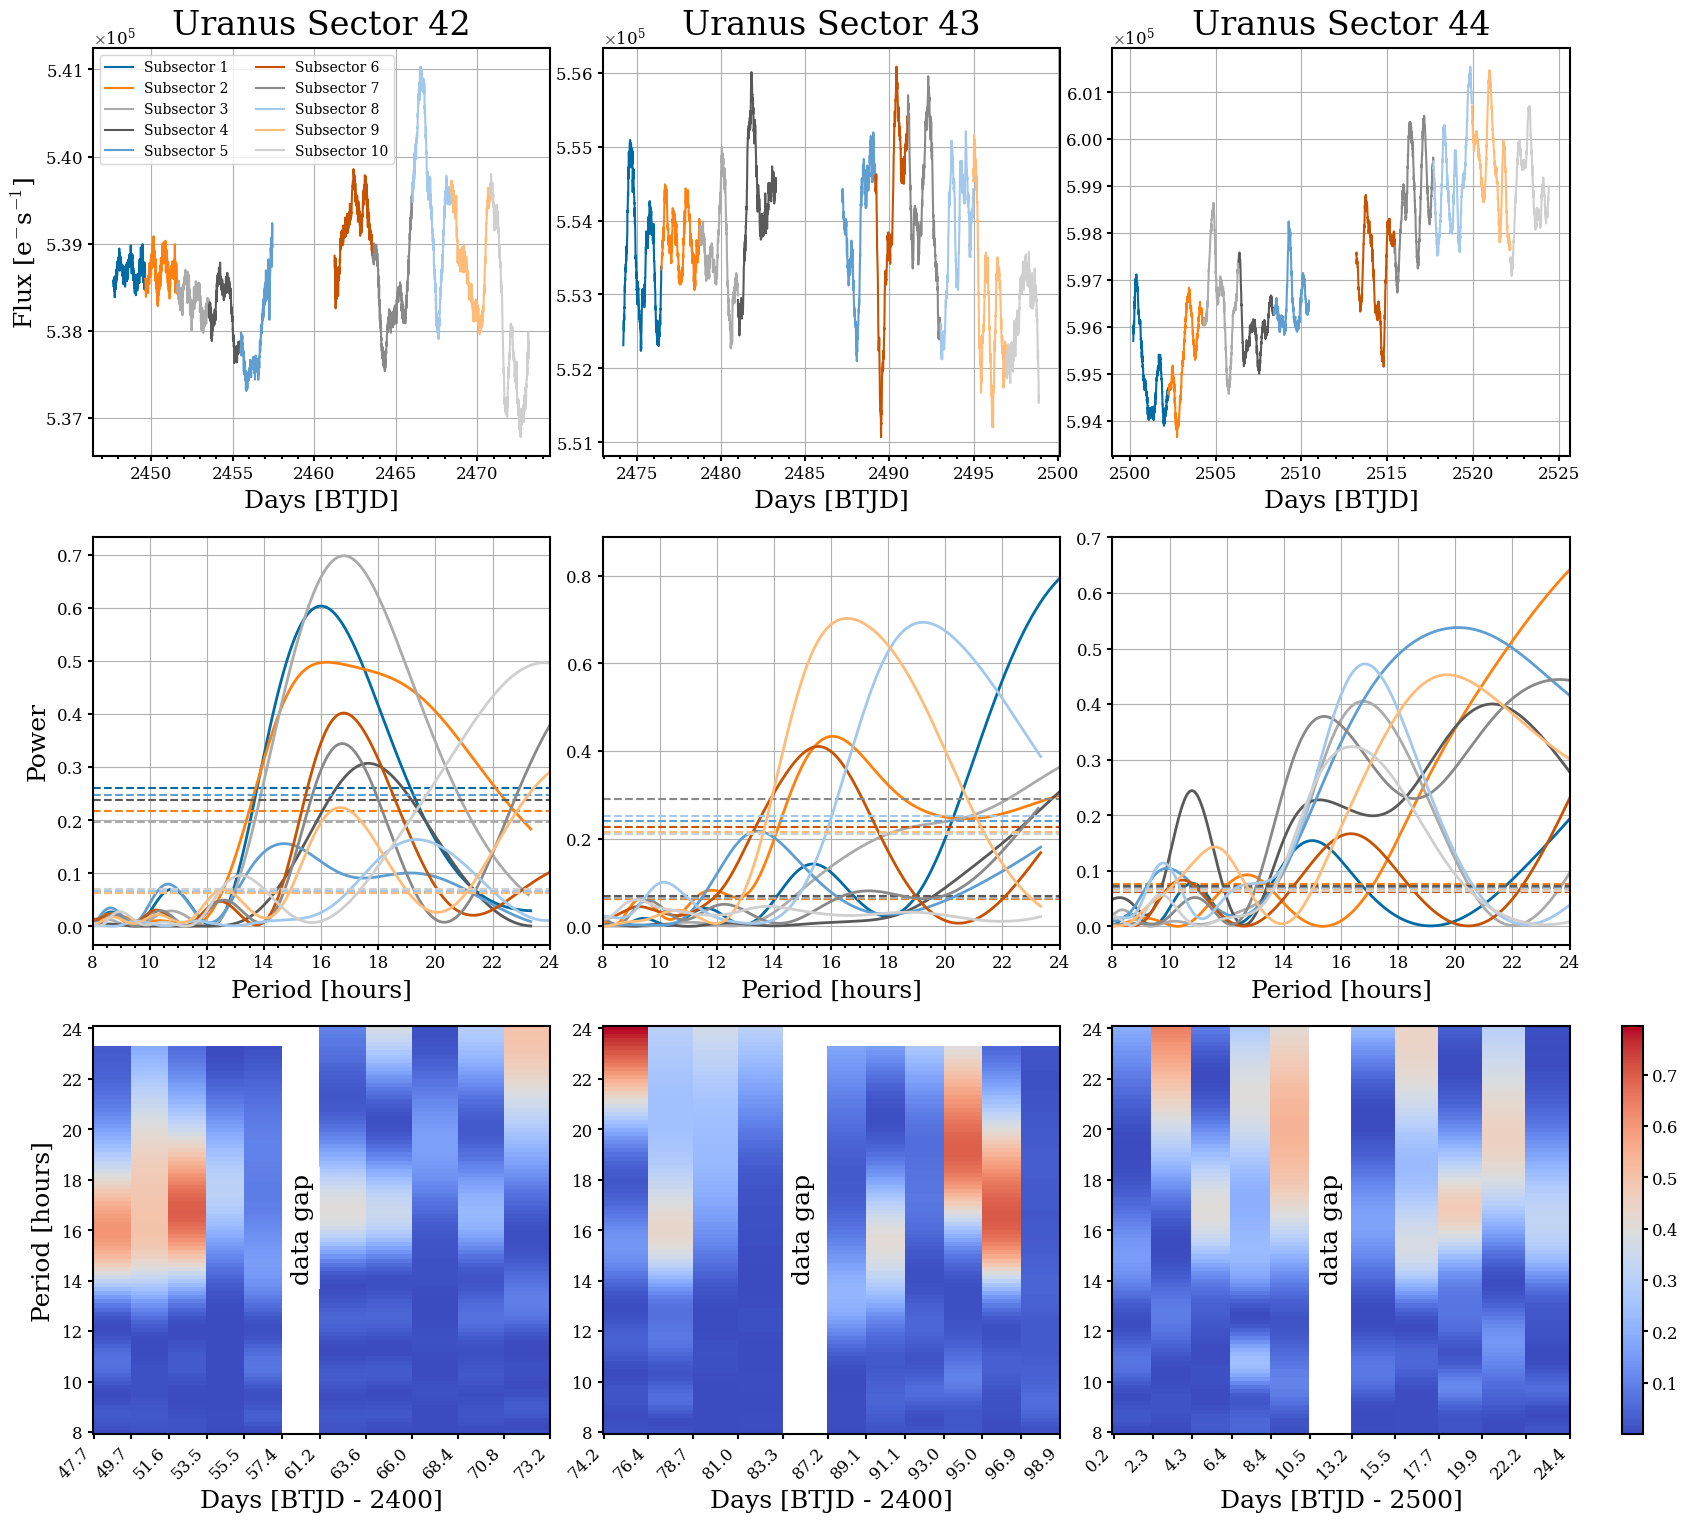

TOTAL BIN TIME: 16.54
time ranges: [1.47 1.47 1.47 1.47 1.78 1.77 1.78 1.78 1.77 1.78]
1.47 1.78
52.1 53.6 61.3
(11, 100)
(100, 222)
(11,)
stretched_rows: 11
x_ticks: [  0  18  36  54  72  90 112 134 156 178 200 222]
x_labels: ['47.7', '49.2', '50.6', '52.1', '53.6', '61.3', '63.1', '64.9', '66.7', '68.4', '70.2', '72.0']
TOTAL BIN TIME: 18.41
time ranges: [1.54 1.54 1.55 1.54 2.03 2.03 2.03 2.05 2.05 2.05]
1.54 2.03
13.0 14.5 21.3
(11, 100)
(100, 220)
(11,)
stretched_rows: 11
x_ticks: [  0  17  34  51  68  85 107 129 151 174 197 220]
x_labels: ['8.4', '9.9', '11.5', '13.0', '14.5', '21.3', '23.4', '25.4', '27.7', '29.7', '31.8', '33.8']


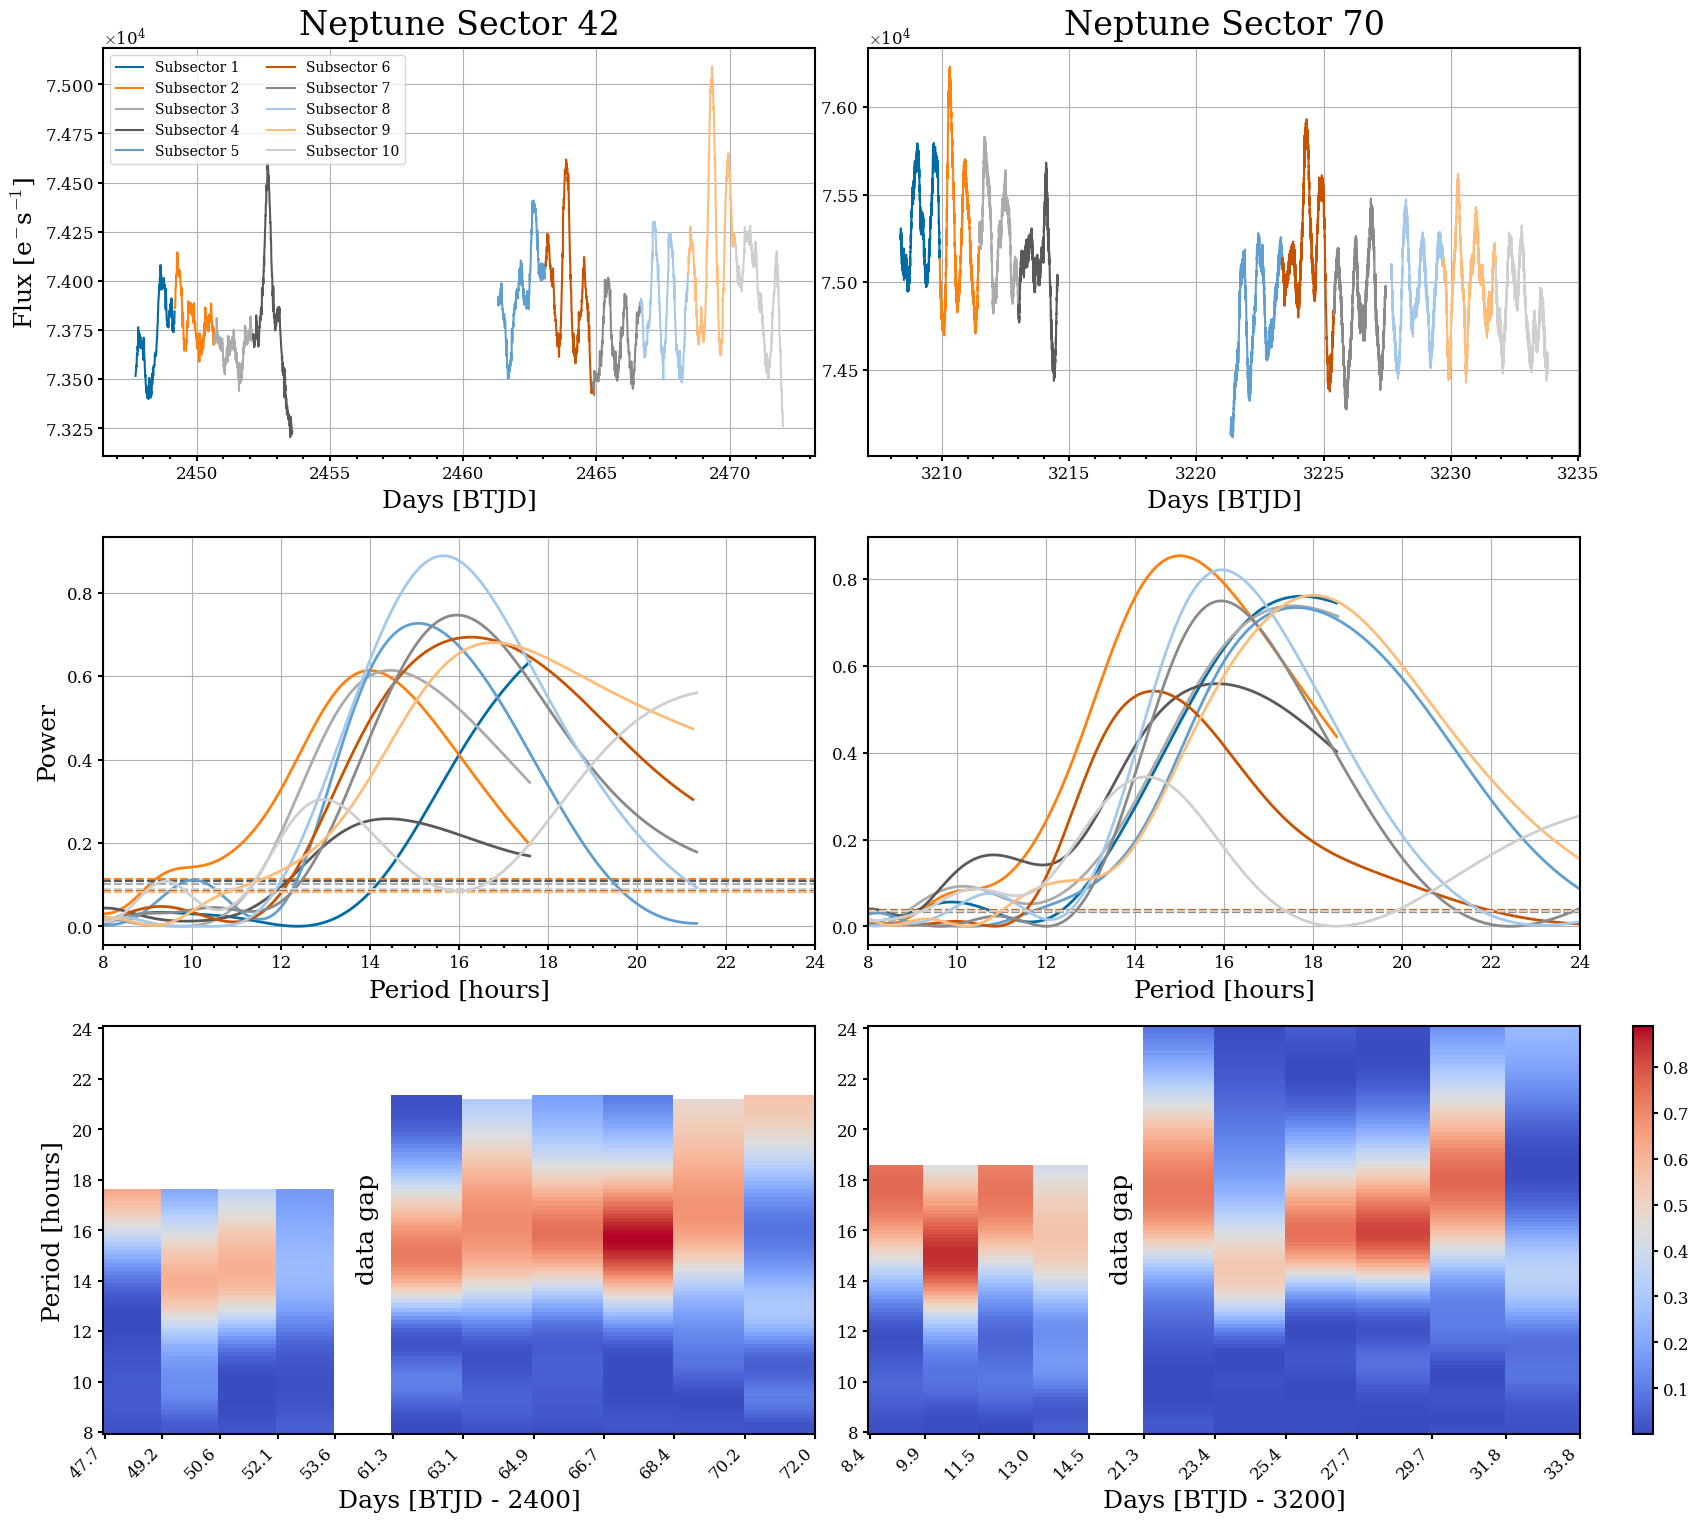

In [58]:
subsectors = np.load(root + 'subsectors/subsectors.npz', allow_pickle=True)
subtimes = subsectors['subtimes']
subfluxes = subsectors['subfluxes']
subfreqs = np.array(subsectors['subfreqs'], dtype=float)
subpower = subsectors['subpower']
subfap = subsectors['subfap']

ur_offset = [2400, 2400, 2500]
uranus_labels = ["Uranus Sector 42", "Uranus Sector 43", "Uranus Sector 44"]
uranus_max_frequency = 1/17.24 #1.394

nep_offset = [2400, 3200]
nep_labels = ["Neptune Sector 42", "Neptune Sector 70"]
neptune_max_frequency = 1/18.86 #1.282201
print(subfreqs[0:3].shape)
plot_subsector_heatmap("Uranus", subtimes[0:3], subfluxes[0:3], 
                       subfreqs[0:3], subpower[0:3], 
                       subfap[0:3], labels=uranus_labels, 
                       max_freq=uranus_max_frequency, 
                       offset=ur_offset, min_per=8, max_per=24)

plot_subsector_heatmap("Neptune", subtimes[3:5], subfluxes[3:5], 
                       subfreqs[3:5], subpower[3:5], 
                       subfap[3:5], labels=nep_labels, 
                       max_freq=neptune_max_frequency, 
                       offset=nep_offset, min_per=8, max_per=24)

In [ ]:
# load the mcmc posteriors back in
pgram_dir = root + "periodograms/"
cluster_dir = root + "clusters/"
lat_dir = root + "latitudes/"

pgram_list, cluster_list, lat_list = [], [], []
for sector in planet_sectors:
    pgram_list.append(np.load(pgram_dir + f"{sector}_periodogram.npz", allow_pickle=True))
    cluster_list.append(np.load(cluster_dir + f"{sector}_clustered_peaks.npz", allow_pickle=True))
    lat_list.append(np.load(lat_dir + f"{sector}_latitude_solutions.npz", allow_pickle=True))

sec_idx = 1
sec_strings = ["Uranus, 42", "Uranus, 43", "Uranus, 44", "Neptune, 42", "Neptune, 70"]

print(pgram_list[sec_idx].keys)
print(cluster_list[sec_idx].keys)
print(lat_list[sec_idx].keys)

def sigma_inverse(x, sigx): # sigma_y for y = 1/x
    sigma_y = sigx / x**2

    return sigma_y

this_ll = lat_list[sec_idx]['lat']
this_std = lat_list[sec_idx]['std']

first_period = cluster_list[sec_idx]['matched_means'][0]
first_std = cluster_list[sec_idx]['matched_stds'][0]

first_period_hrs = np.round(24/first_period, 2)
first_std_hrs = np.round(24*sigma_inverse(first_period, first_std), 2)

print(cluster_list[sec_idx]['matched_stds'][0])
print(f"{sec_strings[sec_idx]} & {first_period_hrs} ± {first_std_hrs}", end=" ")

# print(lat_list[sec_idx]['lat'].shape)
for i in range(len(this_ll)):
    lat = lat_list[sec_idx]['lat'][i][0]
    std = lat_list[sec_idx]['std'][i][0]
    print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")

print("\\\\")

if len(this_ll) > 1:
    for i in range(len(this_ll[:, 1:])):
        print(this_ll[:, 1:][i])



<bound method Mapping.keys of NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/periodograms/u43_periodogram.npz' with keys: frequency, power, false_alarm_levels, peaks, peak_pows>
<bound method Mapping.keys of NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/clusters/u43_clustered_peaks.npz' with keys: matched_means, matched_stds>
<bound method Mapping.keys of NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u43_latitude_solutions.npz' with keys: lat, std, allow_pickle>
0.0065312419577823405
Uranus, 43 & 13.47 ± 0.05 & 27.54 ± 0.76 & 23.84 ± 0.82 & 27.62 ± 0.66 & 23.95 ± 0.72 \\
[37.472505333270426 43.05737737817191]
[36.021981977080166 43.003341724625244]
[37.55864460727749 43.72715746925222]
[36.25208153892782 43.4301699627379]


TypeError: 'numpy.ndarray' object is not callable

In [ ]:
def write_solutions(arrs, sectors, i):
    first_period = np.round(24 / arrs[i].item()['all_peaks'][0][0], decimals=2)
    print(f"{sectors[i]} & {first_period}", end=" ")

    for k in range(len(arrs[i].item()['all_lat'])):
        lat = arrs[i].item()['all_lat'][k][0][0]
        std = arrs[i].item()['all_std'][k][0][0]
        print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")
    
    print("\\\\")

    if len(arrs[i].item()['all_peaks'][0]) > 1:
        for j, peak in enumerate(arrs[i].item()['all_peaks'][0][1:]):
            period = 24 / peak
            print(f"& {np.round(period, decimals=2)} ", end=" ")

            for k in range(len(arrs[i].item()['all_lat'])):
                try:
                    lat = arrs[i].item()['all_lat'][k][0][j + 1]
                    std = arrs[i].item()['all_std'][k][0][j + 1]
                    print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")
                except IndexError:
                    print("& -- ", end=" ")
            
            print("\\\\")        


In [ ]:
sectors = ['42', '43', '44', '42', '70']

print("Sector & Period (hours) & K98_N & K98_S & H01 & S12E & S12E+O_N & S12E+O_S & FAP \\\\")
for i, arr in enumerate(arrs):

    if i == 3:
        print("Sector & Period (hours) & S93_4 & S93_6 & T2013 & T2014 & FAP \\\\")

    write_solutions(arrs, sectors, i)
    print("\hline")

Sector & Period (hours) & K98_N & K98_S & H01 & S12E & S12E+O_N & S12E+O_S & FAP \\
42 & 16.53 & [36.86 88.84] ± [1.2  0.86] & [32.45 89.07] ± [1.09 0.7 ] & [30.94 89.12] ± [1.11 0.7 ] & [34.74 88.97] ± [1.05 0.79] & [35.56 88.94] ± [0.95 0.82] & [33.61 88.94] ± [1.19 0.76] \\
\hline
43 & 17.8 & [ 9.83 89.25] ± [3.71 0.57] & [ 6.88 89.32] ± [2.84 0.51] & [22.42 89.19] ± [1.29 0.6 ] & [25.14 89.1 ] ± [1.82 0.65] & [26.97 89.1 ] ± [1.74 0.68] & [23.39 89.12] ± [1.79 0.66] \\
& 17.04  & [28.66 89.05] ± [1.29 0.72] & [89.17 24.59] ± [0.64 1.18] & [88.97 33.35] ± [0.75 1.1 ] & [36.82 88.87] ± [0.95 0.85] & [37.41 88.9 ] ± [0.85 0.84] & [35.93 88.85] ± [1.08 0.83] \\
& 16.38  & [39.29 88.71] ± [1.21 0.92] & [34.73 88.97] ± [1.08 0.77] & [88.75 41.31] ± [0.94 1.14] & [42.7  88.55] ± [0.78 1.06] & [88.57 42.84] ± [1.07 0.74] & [42.71 88.57] ± [0.9  1.07] \\
& 15.85  & [47.66 88.42] ± [1.36 1.19] & [88.74 42.48] ± [0.96 1.14] & --  & --  & --  & --  \\
\hline
44 & 17.82 & [ 8.76 89.26] ± [3.85 

In [ ]:
s70_s93_4 = np.load("/home/ktp9/TESSNeptune24/tess-ice-giants/neptune_s42_resampled_mcmc_results_s93_4.npy", allow_pickle=True)
keys = ['all_lat', 'all_std', 'all_peaks']

write_solutions([s70_s93_4], ['42'], 0)

42 & 18.34 & [18.8] ± [2.13] \\
& 17.15  & [38.4] ± [1.03] \\
& 16.62  & [44.24] ± [0.89] \\
& 15.98  & [50.14] ± [0.79] \\
& 15.43  & [54.53] ± [0.71] \\
& 14.26  & [62.28] ± [0.59] \\
& 13.85  & [64.59] ± [0.56] \\
& 13.47  & [66.58] ± [0.53] \\
& 13.02  & [68.74] ± [0.5] \\
& 11.71  & [73.98] ± [0.4] \\
